In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    roc_auc_score
)


# Data Preparation

The recession prediction model requires a unified monthly dataset containing recession labels and macroeconomic indicators.

The data preparation process consisted of four steps:

### 1. Construct Monthly Recession Labels

Recession periods were obtained from NBER recession dates. Since recession periods are reported as start and end months, I expanded each recession period into a monthly time series and created a binary target variable:

* 1 = economy was in recession
* 0 = economy was not in recession

This created the dependent variable used in the logistic regression model.

### 2. Establish a Common Monthly Timeline

A monthly date index was created spanning the earliest recession start date through the latest recession end date.

All economic indicators were subsequently merged onto this timeline using observation dates.

### 3. Merge Macroeconomic Indicators

Several predictors commonly associated with business cycle turning points were merged into the master dataset:

| Variable | Description |
|------|------|
| T10Y3M |	10-Year Treasury minus 3-Month Treasury spread |
| DFF | Federal Funds Rate |
| UNRATE | Unemployment Rate |
| CPIAUCSL | Consumer Price Index |
| GDP_PCH | GDP Growth Rate |

### 4. Feature Engineering

Additional transformations were applied:

* Yield curve lags (3 to 6 months)
* Monthly inflation rate derived from CPI
* Quarterly GDP growth converted to monthly frequency using forward-fill interpolation

These transformations allow the model to capture delayed economic effects that may precede recessions.

*The yield curve is often viewed as a leading indicator of recessions. To account for delayed economic effects, lagged yield spread variables ranging from 3 to 6 months were included in the model. This allows the logistic regression to learn whether yield curve inversions precede recession periods several months into the future.*

In [2]:
# --------------------------------------------------
# Create Recession Target Variable
# --------------------------------------------------

recession_dates = pd.read_excel("recession_dates.xlsx")

recession_dates["Start"] = (
    recession_dates["Start"]
    .str.split(r" \(")
    .str[0]
    .pipe(pd.to_datetime, format="%B %Y")
)

recession_dates["End"] = (
    recession_dates["End"]
    .str.split(r" \(")
    .str[0]
    .pipe(pd.to_datetime, format="%B %Y")
)

monthly_dates = pd.date_range(
    start=recession_dates["Start"].min(),
    end=recession_dates["End"].max(),
    freq="MS"
)

df = pd.DataFrame({
    "observation_date": monthly_dates
})

df["recession"] = 0

for _, row in recession_dates.iterrows():
    mask = (
        (df["observation_date"] >= row["Start"]) &
        (df["observation_date"] <= row["End"])
    )
    df.loc[mask, "recession"] = 1

# --------------------------------------------------
# Yield Curve
# --------------------------------------------------

yield_curve = pd.read_excel(
    "T10Y3M.xlsx",
    sheet_name="Monthly"
)

df = yield_curve.merge(
    df,
    how="left",
    on="observation_date"
)

df = df[
    ~df[["T10Y3M", "recession"]]
    .isna()
    .all(axis=1)
]

df["recession"] = df["recession"].fillna(0)

# Create lagged yield curve features

yield_lag_months = [3, 4, 5, 6]

for lag in yield_lag_months:
    df[f"T10Y3M_lag_{lag}"] = df["T10Y3M"].shift(lag)


# --------------------------------------------------
# Federal Funds Rate
# --------------------------------------------------

fed_funds = pd.read_excel(
    "DFF.xlsx",
    sheet_name="Monthly"
)

df = df.merge(
    fed_funds,
    how="left",
    on="observation_date"
)


# --------------------------------------------------
# Unemployment Rate
# --------------------------------------------------

unemployment = pd.read_excel(
    "UNRATE.xlsx",
    sheet_name="Monthly"
)

df = df.merge(
    unemployment,
    how="left",
    on="observation_date"
)

# --------------------------------------------------
# CPI and Inflation Rate
# --------------------------------------------------

cpi = pd.read_excel(
    "CPIAUCSL.xlsx",
    sheet_name="Monthly"
)

df = df.merge(
    cpi,
    how="left",
    on="observation_date"
)

df["inflation_rate"] = (
    df["CPIAUCSL"]
    .pct_change(fill_method=None)
    * 100
)


# --------------------------------------------------
# GDP Growth
# --------------------------------------------------

gdp = pd.read_excel(
    "GDP_PCH.xlsx",
    sheet_name="Quarterly"
)

gdp = (
    gdp
    .set_index("observation_date")
    .resample("MS")
    .ffill()
    .reset_index()
)

df = df.merge(
    gdp,
    how="left",
    on="observation_date"
)

df.head()

,observation_date,T10Y3M,recession,T10Y3M_lag_3,T10Y3M_lag_4,T10Y3M_lag_5,T10Y3M_lag_6,DFF,UNRATE,CPIAUCSL,inflation_rate,GDP_PCH
0,1982-01-01,1.68,1.0,NaN,NaN,NaN,NaN,13.22,8.6,94.4,NaN,-0.19861
1,1982-02-01,0.15,1.0,NaN,NaN,NaN,NaN,14.78,8.9,94.7,0.317797,-0.19861
2,1982-03-01,0.55,1.0,NaN,NaN,NaN,NaN,14.68,9.0,94.7,0.000000,-0.19861
3,1982-04-01,0.53,1.0,1.68,NaN,NaN,NaN,14.94,9.3,95.0,0.316790,1.76129
4,1982-05-01,0.91,1.0,0.15,1.68,NaN,NaN,14.45,9.4,95.9,0.947368,1.76129


# Exploratory Data Analysis

Before fitting the logistic regression model, I explored several macroeconomic indicators to understand how they behaved during historical recession periods.

The shaded regions represent months classified as recessions according to the NBER recession dates. These visualizations provide an intuitive comparison between each economic indicator and recession timing, helping identify whether a variable appears to have predictive value.

In [3]:
def plot_recession_indicator(df, variable, ylabel, title):
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        df["observation_date"],
        df[variable],
        linewidth=2
    )

    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(alpha=0.3)

    ax2 = ax.twinx()

    ax2.fill_between(
        df["observation_date"],
        df["recession"],
        alpha=0.25,
        color="red"
    )

    ax2.set_ylim(0, 1)
    ax2.set_yticks([])

    plt.tight_layout()
    plt.show()

## Yield Curve

The yield spread frequently became negative prior to several recessions, suggesting that yield curve inversions may serve as a leading indicator of economic downturns. This supports its inclusion as one of the primary predictors in the logistic regression model.

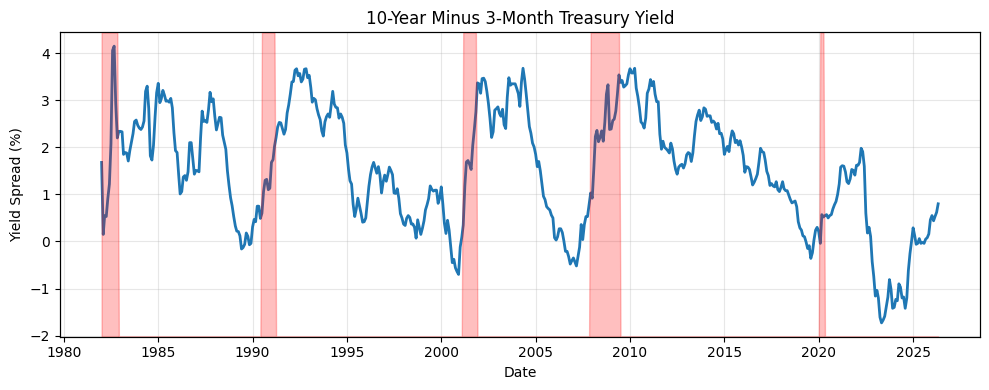

In [4]:
plot_recession_indicator(
    df,
    "T10Y3M",
    "Yield Spread (%)",
    "10-Year Minus 3-Month Treasury Yield"
)

## Unemployment

Unemployment generally increased during recession periods rather than before them. This suggests that unemployment may behave more as a coincident or lagging indicator than a leading indicator, though it may still improve model performance when combined with other variables.

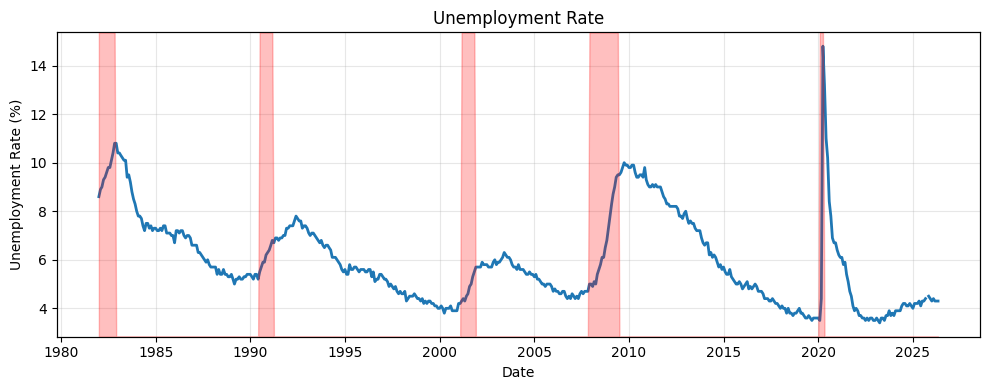

In [5]:
plot_recession_indicator(
    df,
    "UNRATE",
    "Unemployment Rate (%)",
    "Unemployment Rate"
)

## GDP

GDP growth consistently weakened during recessions, often turning negative. Since GDP is released quarterly and may not provide substantial lead time, it is expected to have less predictive power than forward-looking financial indicators such as the yield curve.

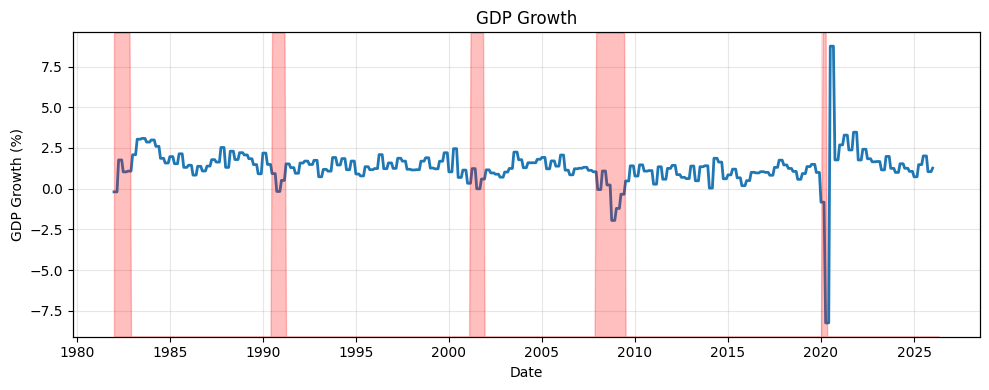

In [6]:
plot_recession_indicator(
    df,
    "GDP_PCH",
    "GDP Growth (%)",
    "GDP Growth"
)

# Modeling

The objective of this analysis is to estimate the probability that the U.S. economy is in a recession using several macroeconomic indicators.

Logistic regression was selected because the response variable is binary:

* 0 = No recession
* 1 = Recession

Unlike linear regression, logistic regression estimates the probability of recession by modeling the log-odds of the binary outcome.

The model includes:

* Yield curve lags (3 to 6 months)
* Federal Funds Rate
* Unemployment Rate
* Inflation Rate
* GDP Growth

To evaluate generalization, the model is trained using observations before January 2015 and evaluated on later observations.

In [7]:
valid_rows = (df['T10Y3M_lag_6'].notna()) 

feature_names = [
    "T10Y3M_lag_3",
    "T10Y3M_lag_4",
    "T10Y3M_lag_5",
    "T10Y3M_lag_6",
    "DFF",
    "UNRATE",
    "inflation_rate",
    "GDP_PCH"
]

X = df[valid_rows][["observation_date",*feature_names]]
y = df[valid_rows][["observation_date","recession"]]

cutoff_date = pd.to_datetime("2015-01-01")

train_filter = (X['observation_date']<cutoff_date)


X_train = X[train_filter].drop(columns="observation_date")
y_train = y[train_filter]["recession"]

test_results = pd.concat(
    [X[~train_filter], y[~train_filter].drop(columns='observation_date')],
    axis=1
)

test_results = test_results[~test_results.isna().any(axis=1)]

logit_model = LogisticRegression(fit_intercept=True)
logit_model.fit(X_train, y_train)


test_results['recession_logit'] = logit_model.intercept_ + (
    logit_model.coef_[0] * test_results[feature_names]
).sum(axis=1)


test_results["recession_probability"] = (
    logit_model.predict_proba(test_results[feature_names])[:, 1]
)

## Estimated Logistic Regression Equation

The logistic regression model estimates the **log-odds** of a recession as a linear combination of the predictor variables.

$$
\log\left(\frac{p}{1-p}\right)
=
\beta_0
+
\beta_1X_1
+
\beta_2X_2
+
\cdots
+
\beta_nX_n
$$

where

- $p$ is the probability that the economy is in a recession.
- $\beta_0$ is the intercept.
- $\beta_i$ are the estimated coefficients.
- $X_i$ are the predictor variables.

In [8]:
temp = [f"{'+' * int(j>=0)} {j:.04f} * {i}" for i, j in zip(feature_names, logit_model.coef_[0])]

print(f"Estimated Logistic Regression Equation\nlog(p / (1 − p)) = {logit_model.intercept_[0]:0.04f} {" ".join(temp)}")

Estimated Logistic Regression Equation
log(p / (1 − p)) = -0.4948 + 0.9218 * T10Y3M_lag_3  -0.3638 * T10Y3M_lag_4  -0.4044 * T10Y3M_lag_5  -1.3689 * T10Y3M_lag_6 + 0.1074 * DFF + 0.3600 * UNRATE + 0.5543 * inflation_rate  -3.2041 * GDP_PCH


## Observations

Among the included predictors, GDP growth has the largest negative coefficient (-3.20). This suggests that stronger economic growth is associated with a lower estimated probability of recession, which is consistent with economic intuition.

The six-month lag of the 10-Year Minus 3-Month Treasury Yield Spread also has a relatively large negative coefficient (-1.37). Historically, an inverted yield curve has often preceded recessions, making the yield spread a widely used leading economic indicator.

Conversely, inflation, unemployment, and the Federal Funds Rate have positive coefficients in the fitted model, indicating that higher values of these variables are associated with higher estimated recession probabilities after accounting for the remaining predictors.

The presence of both positive and negative coefficients among the lagged yield spread variables suggests that the relationship between the yield curve and recession risk evolves over time. Since these lagged variables are highly correlated with one another, their individual coefficients should be interpreted with caution.

In [9]:
coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logit_model.coef_[0]
})

coef_table.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
7,GDP_PCH,-3.204095
3,T10Y3M_lag_6,-1.368943
0,T10Y3M_lag_3,0.921765
6,inflation_rate,0.554349
2,T10Y3M_lag_5,-0.404361
1,T10Y3M_lag_4,-0.363809
5,UNRATE,0.359954
4,DFF,0.107393


While the coefficient estimates provide insight into the relationship between macroeconomic indicators and recession probability, the primary goal of this project is prediction rather than causal inference. Therefore, the next section evaluates how well the fitted model predicts recession periods on out-of-sample data.

# Model Evaluation

To evaluate the model's predictive performance, the logistic regression model was applied to observations occurring after January 2015. Because these observations were not used during model training, they provide an opportunity to assess how well the model generalizes to unseen data.

Rather than predicting only recession or non-recession, the model estimates the probability that the economy is in a recession for each month. Comparing these probabilities with the observed recession periods helps determine whether the model identifies periods of elevated recession risk.

## Observation: Data Visualization

The predicted recession probabilities generally increase during recession periods while remaining relatively low during periods of economic expansion. This indicates that the model captures much of the underlying relationship between macroeconomic indicators and historical recessions.

The probability estimates also tend to rise before several recession periods, suggesting that the selected economic indicators contain useful forward-looking information.

However, the model does not perfectly align with every recession period. Some recession months receive relatively low probabilities, while certain non-recession months exhibit elevated probabilities. These discrepancies illustrate the inherent uncertainty involved in forecasting macroeconomic conditions.

Overall, the model demonstrates that logistic regression can effectively estimate recession risk using publicly available economic indicators, although additional predictors or alternative modeling techniques may further improve predictive performance.

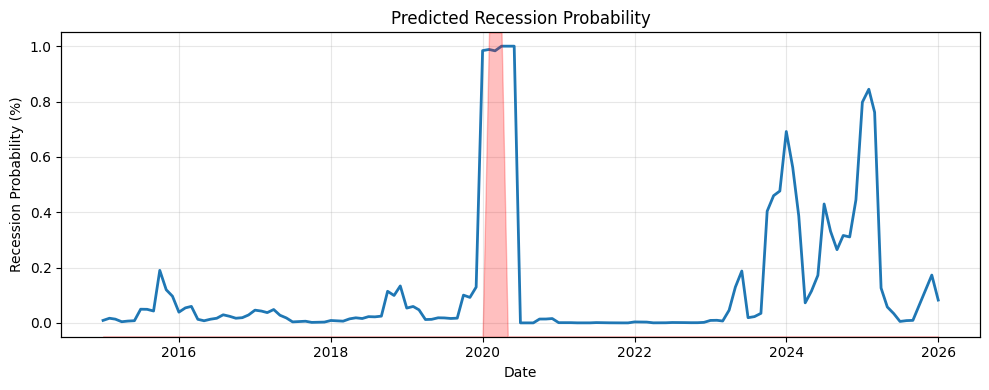

In [10]:
plot_recession_indicator(
    test_results,
    "recession_probability",
    "Recession Probability (%)",
    "Predicted Recession Probability"
)

### Findings

The model successfully identified the sharp increase in recession risk during the COVID-19 recession. Predicted probabilities exceeded 98% during the official recession period, demonstrating that the selected macroeconomic indicators effectively captured the rapid deterioration in economic conditions.

Outside of recession periods, the model generally assigned low recession probabilities throughout the prolonged economic expansion between 2015 and 2019, suggesting that it distinguished stable economic conditions from periods of elevated risk.

The model also produced elevated recession probabilities during several periods that were not officially classified as recessions, particularly during late 2023 through early 2025. These predictions indicate that the macroeconomic conditions during those periods resembled historical recession patterns, although an official recession did not occur.

Overall, the model demonstrates that logistic regression can effectively estimate recession risk using a relatively small collection of macroeconomic indicators. However, the results also illustrate the difficulty of forecasting business cycles, where economic conditions may resemble recessionary environments without ultimately resulting in an officially declared recession.

The logistic regression model estimates the probability that the U.S. economy is in a recession for each monthly observation. Because the model outputs probabilities ranging from 0 to 1, a classification threshold is needed to convert these probabilities into binary predictions.

For this analysis, a threshold of **0.50** is used:

- **Predicted Probability ≥ 0.50** → Predict **Recession (1)**
- **Predicted Probability < 0.50** → Predict **No Recession (0)**

Using a threshold of 0.50 is a common starting point because it classifies an observation as a recession only when the estimated probability exceeds 50%.

It is important to note that the threshold does **not** affect the estimated probabilities themselves. Instead, it determines how those probabilities are translated into discrete recession predictions. Depending on the goals of the analysis, the threshold can be adjusted to balance false positives and false negatives. For example, lowering the threshold would identify more potential recessions but may also increase false alarms, while raising the threshold would produce fewer false alarms at the risk of missing some recession periods.

In [11]:
test_results["predicted_class"] = (
    test_results["recession_probability"] >= 0.5
).astype(int)

## Observation: Classification Performance

The logistic regression model successfully identified all three recession observations in the test dataset, resulting in a recall of 100%. In other words, the model did not miss any historical recession months during the evaluation period.

Among the 128 non-recession observations, 120 were correctly classified while 8 were incorrectly predicted as recessions. These false positives reduced the model's precision to 27.3%, indicating that many predicted recessions did not actually occur.

The model achieved an overall accuracy of 93.9%, demonstrating strong performance in identifying non-recession periods while also detecting every observed recession.

Because recession months are relatively rare in the dataset, accuracy alone does not fully describe model performance. The combination of perfect recall and lower precision suggests that the model favors identifying potential recessions, even at the cost of generating additional false alarms.

Overall, the results indicate that the model is effective at detecting recession periods, although it tends to overpredict recession risk during some expansionary periods.

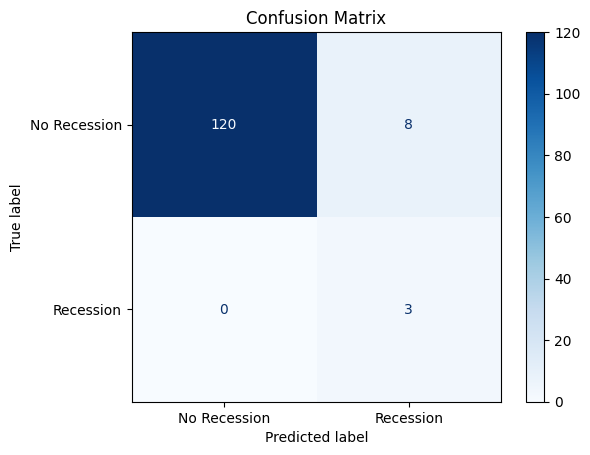

In [12]:

cm = confusion_matrix(
    test_results["recession"],
    test_results["predicted_class"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Recession", "Recession"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In [13]:


# Evaluate classification performance

accuracy = accuracy_score(
    test_results["recession"],
    test_results["predicted_class"]
)

precision = precision_score(
    test_results["recession"],
    test_results["predicted_class"]
)

recall = recall_score(
    test_results["recession"],
    test_results["predicted_class"]
)

f1 = f1_score(
    test_results["recession"],
    test_results["predicted_class"]
)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

Accuracy : 0.939
Precision: 0.273
Recall   : 1.000
F1 Score : 0.429


### Interpretation

The ROC curve summarizes the model's performance across all possible probability thresholds. The calculated AUC provides a single measure of how effectively the model distinguishes recession periods from non-recession periods.

A higher AUC indicates that recession months generally receive higher predicted probabilities than non-recession months. Together with the probability time series and classification metrics, the ROC curve provides additional evidence regarding the model's predictive capability.

## Observation: Receiver Operating Characteristic (ROC) Curve

The logistic regression model achieved an AUC of 0.987, indicating excellent discrimination between recession and non-recession periods in the test dataset.

The ROC curve rises sharply toward the upper-left corner, demonstrating that the model is able to achieve high true positive rates while maintaining relatively low false positive rates across a wide range of probability thresholds.

Combined with the confusion matrix, these results suggest that the selected macroeconomic indicators contain substantial information for distinguishing recession periods from economic expansions.

Although the ROC curve indicates strong predictive performance, the evaluation dataset contains only three recession observations. Consequently, the AUC estimate should be interpreted with appropriate caution, as performance metrics may vary when evaluated on additional recession periods.

Overall, the ROC analysis supports the conclusion that logistic regression provides an effective framework for estimating recession probabilities using historical macroeconomic indicators.

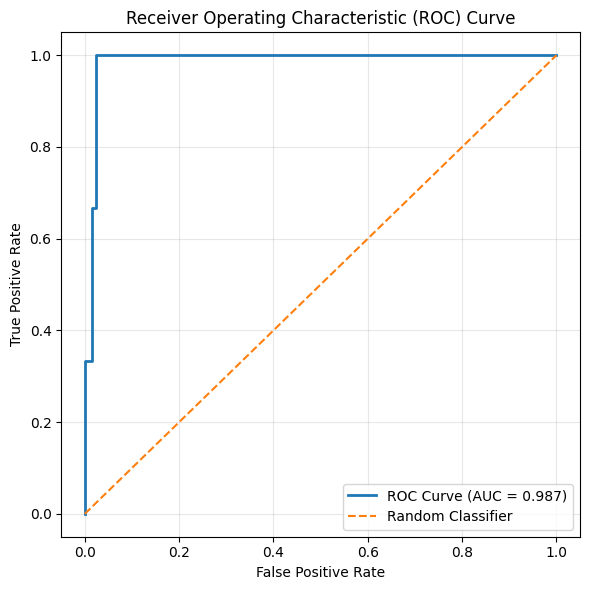

In [14]:

# Calculate false positive rate, true positive rate, and thresholds

fpr, tpr, thresholds = roc_curve(
    test_results["recession"],
    test_results["recession_probability"]
)

auc = roc_auc_score(
    test_results["recession"],
    test_results["recession_probability"]
)

# Plot ROC Curve

plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {auc:.3f})"
)

# Random classifier reference line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Conclusion



This project demonstrated how logistic regression can be used to estimate the probability of U.S. recessions using publicly available macroeconomic indicators. Beginning with historical recession dates and several economic time series, a complete machine learning pipeline was developed, including data preparation, feature engineering, exploratory data analysis, model training, and out-of-sample evaluation.

The exploratory analysis showed that several economic indicators exhibited recognizable patterns around historical recession periods. In particular, lagged yield curve spreads and GDP growth displayed relationships that supported their inclusion as predictive features.

After training the logistic regression model using historical observations prior to 2015, the model was evaluated on a held-out test dataset. The model achieved:

| Metric    |    Result |
| --------- | --------: |
| Accuracy  | **93.9%** |
| Recall    |  **100%** |
| Precision | **27.3%** |
| AUC       | **0.987** |

These results indicate that the model successfully identified all observed recession months in the test period while maintaining a relatively low number of false positives. The high AUC further suggests that the model effectively distinguishes between recession and non-recession periods across a range of classification thresholds.

While the evaluation results are encouraging, several limitations should be acknowledged. Recession periods are relatively rare events, and the test dataset contained only three recession observations. As a result, the reported performance metrics should be interpreted cautiously, as they may vary when evaluated on additional economic cycles. Furthermore, the model assumes a linear relationship between the predictors and the log-odds of recession, which may not fully capture the complexity of macroeconomic dynamics.

Future improvements could include expanding the feature set with additional leading economic indicators, evaluating alternative lag structures, applying regularized logistic regression for feature selection, or comparing performance against more advanced machine learning models such as Random Forests, Gradient Boosting, or XGBoost. Cross-validation and rolling-window evaluation could also provide a more robust assessment of predictive performance over multiple business cycles.

Overall, this project demonstrates how economic data, feature engineering, and statistical modeling can be combined to estimate recession probabilities in an interpretable and reproducible framework. Beyond developing a predictive model, the project highlights the complete data science workflow, from data acquisition and preparation through model interpretation and performance evaluation, providing a practical example of applying machine learning techniques to a real-world economic forecasting problem.